In [115]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [116]:
f_sig = "../coffea/AllInOne_2022/Resolution_DSCBsigma.coffea"

sig_histo = util.load(f_sig) [0]


Hist(
  Variable(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.]), name='Gen_pt'),
  Regular(200, -1, 1, name='Res_GED'),
  storage=Weight()) # Sum: WeightedSum(value=159, variance=159) (WeightedSum(value=166, variance=166) with flow)


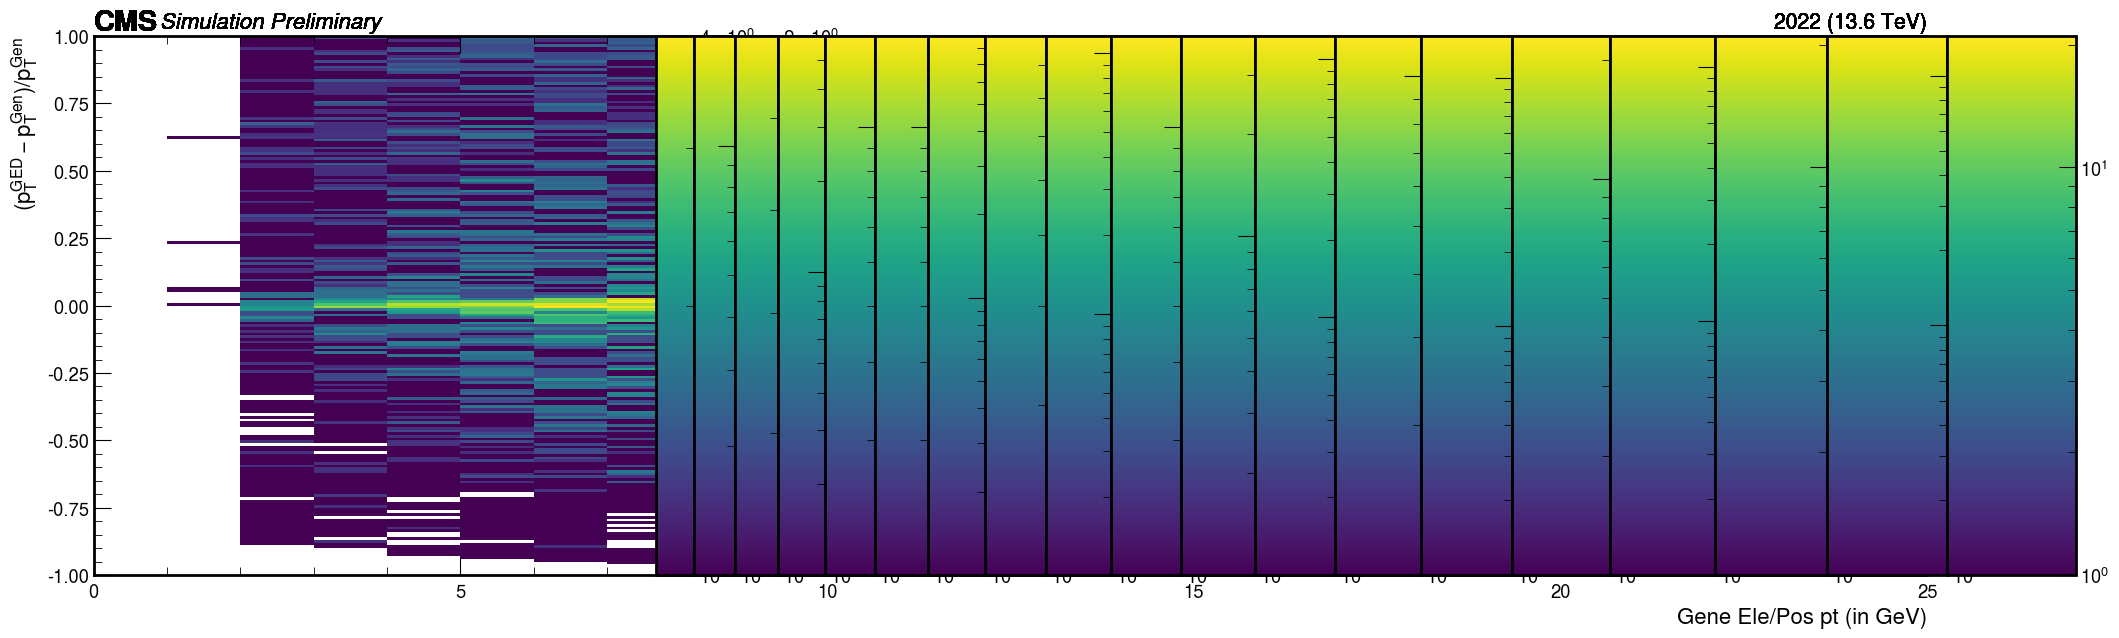

In [117]:
fig, ax = plt.subplots(figsize=(7,7))


# Plot settings
plot_dict = {
    'variable':'res_GED_gen_ptbin',
    'cut': 'cut1',
    'year': 2022
}


style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "Gene Ele/Pos pt (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': None,   
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}

#signal points
samples = {
    10: 
    {
        0.1: [10],
        0.2: [1,100],
    },
    20: 
    {
        
        0.2: [1, 100],
    },
    30: 
    {
        0.1: [10],
        0.2: [1,100]
    },
    40: 
    {
        0.2: [1, 100],
    },
    50:
    {
        0.1: [10],
        0.2: [1,100],
    },
    60:
    {
         0.2: [1,100],
    },
    70:
    {
         0.2: [1,100],
    },
    80:
    {
         0.2: [1,100],
    }
 
}


h_list_lpt=[]
h_sum_lpt = None

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h_lpt = ptools.plot_signal_2D(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict)
            h_list_lpt.append(h_lpt)            
            if h_sum_lpt is None:
                h_sum_lpt = h_lpt.copy()
                print (h_sum_lpt)
            else:
                h_sum_lpt += h_lpt



In [122]:
n_pt_bins=len(h_sum_lpt.axes[0].edges)


fit_inputs = []

for pt_bin_index in range(5):
    hist_slice = h_sum_lpt[pt_bin_index,:]
    counts = hist_slice.values()
    resolution_edges = hist_slice.axes[0].edges

    resolution_bin_centers = (resolution_edges[:-1] + resolution_edges[1:]) / 2
    
    variances = hist_slice.variances()    
    y_errors = np.sqrt(variances)
    

    fit_inputs.append({
        "pt_bin_index": pt_bin_index,        
        "hist": hist_slice,
        "x": resolution_bin_centers,
        "y": counts,
        "yerr": y_errors,
    })
    
print (fit_inputs)

[{'pt_bin_index': 0, 'hist': Hist(Regular(200, -1, 1, name='Res_GED'), storage=Weight()) # Sum: WeightedSum(value=0, variance=0), 'x': array([-0.995, -0.985, -0.975, -0.965, -0.955, -0.945, -0.935, -0.925,
       -0.915, -0.905, -0.895, -0.885, -0.875, -0.865, -0.855, -0.845,
       -0.835, -0.825, -0.815, -0.805, -0.795, -0.785, -0.775, -0.765,
       -0.755, -0.745, -0.735, -0.725, -0.715, -0.705, -0.695, -0.685,
       -0.675, -0.665, -0.655, -0.645, -0.635, -0.625, -0.615, -0.605,
       -0.595, -0.585, -0.575, -0.565, -0.555, -0.545, -0.535, -0.525,
       -0.515, -0.505, -0.495, -0.485, -0.475, -0.465, -0.455, -0.445,
       -0.435, -0.425, -0.415, -0.405, -0.395, -0.385, -0.375, -0.365,
       -0.355, -0.345, -0.335, -0.325, -0.315, -0.305, -0.295, -0.285,
       -0.275, -0.265, -0.255, -0.245, -0.235, -0.225, -0.215, -0.205,
       -0.195, -0.185, -0.175, -0.165, -0.155, -0.145, -0.135, -0.125,
       -0.115, -0.105, -0.095, -0.085, -0.075, -0.065, -0.055, -0.045,
       -0.035

In [127]:
for data in fit_inputs:

    x = data["x"]
    y = data["y"]
    yerr = data["yerr"]

    mask = (
        (y > 0)
        & (yerr > 0)
    )

    data["x_fit"] = x[mask]
    data["y_fit"] = y[mask]
    data["yerr_fit"] = yerr[mask]


In [128]:
n_fit_parameters = 7

valid_fit_inputs = [
    data
    for data in fit_inputs
    if len(data["x_fit"]) > n_fit_parameters
]
print (valid_fit_inputs)

[{'pt_bin_index': 2, 'hist': Hist(Regular(200, -1, 1, name='Res_GED'), storage=Weight()) # Sum: WeightedSum(value=3153, variance=3153) (WeightedSum(value=4874, variance=4874) with flow), 'x': array([-0.995, -0.985, -0.975, -0.965, -0.955, -0.945, -0.935, -0.925,
       -0.915, -0.905, -0.895, -0.885, -0.875, -0.865, -0.855, -0.845,
       -0.835, -0.825, -0.815, -0.805, -0.795, -0.785, -0.775, -0.765,
       -0.755, -0.745, -0.735, -0.725, -0.715, -0.705, -0.695, -0.685,
       -0.675, -0.665, -0.655, -0.645, -0.635, -0.625, -0.615, -0.605,
       -0.595, -0.585, -0.575, -0.565, -0.555, -0.545, -0.535, -0.525,
       -0.515, -0.505, -0.495, -0.485, -0.475, -0.465, -0.455, -0.445,
       -0.435, -0.425, -0.415, -0.405, -0.395, -0.385, -0.375, -0.365,
       -0.355, -0.345, -0.335, -0.325, -0.315, -0.305, -0.295, -0.285,
       -0.275, -0.265, -0.255, -0.245, -0.235, -0.225, -0.215, -0.205,
       -0.195, -0.185, -0.175, -0.165, -0.155, -0.145, -0.135, -0.125,
       -0.115, -0.105, -0.0